# Gender equality in leadership: A data-driven analysis
## Investigating factors that drive female representation in management

**Author:** Jéssica Villar

**Date:** February 2026 

**Dataset:** World Bank Gender Statistics (17 Latin American countries, 2015-2024)

### Executive Summary

This project investigates **factors influencing female representation in business leadership positions** using World Bank data with **complete preprocessing pipeline** including pivot tables and null value handling.

### Key business questions

1. Which educational factors have the greatest impact on female leadership?
2. How does economic development influence gender equality?
3. What is the relationship between employment quality and female leadership?
4. Which interventions provide the highest ROI?

# 1. Setup and configurations

In [1]:
!pip install openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.9/250.9 kB 5.8 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Data manipulation
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Custom class
from gender_equality_analyzer import GenderEqualityAnalyzer

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

# 2. Data loading and preprocessing

In [3]:
# Initialize analyzer
analyzer = GenderEqualityAnalyzer()

# Load data
analyzer.load_world_bank_data(
    filepath='p_data_extract_from_gender_statistics.xlsx',
#     value_col='value',  # Column containing numeric values
#     convert_missing=True  # Convert '..' to NaN
)

Data loaded successfully!
  Dimensions: 423 rows x 14 columns
  Data period: 2015 - 2024
  Years available: 10


,Series Name,Series Code,Country Name,Country Code,2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024]
0,"Female share of graduates from Science, Techno...",SE.TER.GRAD.FE.SI.ZS,Brazil,BRA,34.446522,35.20026,36.644058,35.011391,35.011002,33.679611,..,31.872761,30.52029,..
1,"Female share of graduates from Science, Techno...",SE.TER.GRAD.FE.SI.ZS,Mexico,MEX,31.331949,31.133751,30.628151,..,31.262871,32.070141,32.908489,33.673168,34.420769,..
2,"Female share of graduates from Science, Techno...",SE.TER.GRAD.FE.SI.ZS,Argentina,ARG,..,..,..,47.565578,48.353649,48.598209,47.93745,48.476681,46.754929,..
3,"Female share of graduates from Science, Techno...",SE.TER.GRAD.FE.SI.ZS,Chile,CHL,18.209129,18.47369,18.828581,18.67831,19.15946,20.08836,19.54347,20.935011,20.56444,..
4,"Female share of graduates from Science, Techno...",SE.TER.GRAD.FE.SI.ZS,Bolivia,BOL,..,..,..,..,..,..,..,..,..,..
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
419,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
420,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
421,Data from database: Gender Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Transform to long
analyzer.transform_to_long()

Transforming from wide to long format...
   ID variables: ['Country Name', 'Country Code', 'Series Code']
   Year columns: 10
   Transformation complete!
   Long format: 2,929 rows
   Removed 1,301 rows with null values


,Country Name,Country Code,Series Code,value,year
0,Brazil,BRA,SE.TER.GRAD.FE.SI.ZS,34.446522,2015
1,Mexico,MEX,SE.TER.GRAD.FE.SI.ZS,31.331949,2015
3,Chile,CHL,SE.TER.GRAD.FE.SI.ZS,18.209129,2015
5,Colombia,COL,SE.TER.GRAD.FE.SI.ZS,33.118610,2015
6,Ecuador,ECU,SE.TER.GRAD.FE.SI.ZS,28.070391,2015
...,...,...,...,...,...
4190,Peru,PER,SI.POV.GINI,40.100000,2024
4192,Uruguay,URY,SI.POV.GINI,40.000000,2024
4195,Dominican Republic,DOM,SI.POV.GINI,39.000000,2024
4197,Panama,PAN,SI.POV.GINI,49.700000,2024


In [5]:
# Map World Bank codes to readable names
analyzer.map_variables(
    series_code_col='Series Code',
    keep_unmapped=False  # Remove indicators not in our mapping (recommended)
)

Mapping World Bank variable codes to readable names...
   Total mapping rules: 19
   Mapped: 2,929 rows (692.4%)
   Unmapped: 0 rows (0.0%)
   Removed 0 unmapped rows
   Final: 2,929 rows with 19 unique variables


,Country Name,Country Code,Series Code,value,year,variable_name
0,Brazil,BRA,SE.TER.GRAD.FE.SI.ZS,34.446522,2015,pct_graduadas_stem
1,Mexico,MEX,SE.TER.GRAD.FE.SI.ZS,31.331949,2015,pct_graduadas_stem
3,Chile,CHL,SE.TER.GRAD.FE.SI.ZS,18.209129,2015,pct_graduadas_stem
5,Colombia,COL,SE.TER.GRAD.FE.SI.ZS,33.118610,2015,pct_graduadas_stem
6,Ecuador,ECU,SE.TER.GRAD.FE.SI.ZS,28.070391,2015,pct_graduadas_stem
...,...,...,...,...,...,...
4190,Peru,PER,SI.POV.GINI,40.100000,2024,indice_gini
4192,Uruguay,URY,SI.POV.GINI,40.000000,2024,indice_gini
4195,Dominican Republic,DOM,SI.POV.GINI,39.000000,2024,indice_gini
4197,Panama,PAN,SI.POV.GINI,49.700000,2024,indice_gini


In [6]:
# Pivot to wide format
analyzer.pivot_data(
    index_cols=['Country Name', 'Country Code', 'year'],  # Unique observation identifiers
    columns_col='variable_name',  # Column with readable indicator names
    values_col='value'            # Column with numeric values
)

Pivoting data from long to wide format...
   Index columns: ['Country Name', 'Country Code', 'year']
   Columns from: variable_name
   Values from: value
Pivoting complete!
Wide format: 220 rows x 22 columns
Created 19 indicator columns


,Country Name,Country Code,year,desemprego_edu_avancada_feminino,desemprego_edu_avancada_masculino,desemprego_feminino,desemprego_masculino,empregadas_assalariadas,empregados_assalariados,empresas_gerente_feminina,...,indice_gini,matricula_secundaria_feminina,matricula_superior_feminina,mulheres_parlamento,participacao_trabalho_feminina,pct_graduadas_stem,pct_mulheres_gerencia,pib_per_capita,razao_fm_participacao_trabalho,uso_internet
0,Argentina,ARG,2015,NaN,NaN,8.704,6.796,79.918961,72.997085,NaN,...,NaN,111.491547,105.026185,NaN,47.498,NaN,NaN,13679.626498,66.451216,68.0431
1,Argentina,ARG,2016,NaN,NaN,9.227,7.291,79.242334,72.442691,NaN,...,42.3,112.874443,109.302620,35.797665,47.582,NaN,NaN,12699.962314,67.066020,70.9690
2,Argentina,ARG,2017,3.971,2.322,9.485,7.544,78.597119,71.942072,7.985743,...,41.4,113.530090,112.844352,38.132296,47.666,NaN,32.629,14532.500931,67.693925,74.2949
3,Argentina,ARG,2018,4.201,2.881,10.563,8.246,77.472436,72.348449,NaN,...,41.7,112.869537,114.838632,38.910506,49.146,47.565578,33.178,11752.799892,69.744274,77.7000
4,Argentina,ARG,2019,4.395,3.180,10.718,9.202,76.633238,71.232437,NaN,...,43.3,113.605873,120.836338,40.157480,50.000,48.353649,33.136,9955.974787,70.441386,79.9470
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,"Venezuela, RB",VEN,2020,NaN,NaN,7.907,7.287,64.085996,57.891393,NaN,...,NaN,NaN,NaN,22.155689,36.887,NaN,NaN,1506.043621,61.461943,NaN
216,"Venezuela, RB",VEN,2021,NaN,NaN,7.541,6.693,65.579221,58.434215,NaN,...,NaN,NaN,NaN,22.155689,37.368,NaN,NaN,2004.933979,61.855261,NaN
217,"Venezuela, RB",VEN,2022,NaN,NaN,6.179,5.352,63.856243,58.325870,NaN,...,NaN,100.249550,NaN,NaN,35.320,NaN,NaN,3155.042071,52.536070,NaN
218,"Venezuela, RB",VEN,2023,NaN,NaN,5.937,5.108,63.003974,57.953062,NaN,...,NaN,101.692711,NaN,NaN,36.158,NaN,NaN,3617.435946,53.687508,NaN


In [7]:
# Remove columns with >60% null values
analyzer.remove_high_null_columns(
    threshold=0.6,  # Maximum 60% nulls allowed
    verbose=True    # Print removed columns
)

Removing columns with >60% null values...

   Columns being removed (3):
      - empresas_gerente_feminina                                              (90.9% null)
      - empresas_proprietaria_feminina                                         (90.9% null)
      - indice_capital_humano                                                  (76.8% null)

   Removed 3 columns
   Remaining: 19 columns
   Data shape: 220 rows x 19 columns


,Country Name,Country Code,year,desemprego_edu_avancada_feminino,desemprego_edu_avancada_masculino,desemprego_feminino,desemprego_masculino,empregadas_assalariadas,empregados_assalariados,indice_gini,matricula_secundaria_feminina,matricula_superior_feminina,mulheres_parlamento,participacao_trabalho_feminina,pct_graduadas_stem,pct_mulheres_gerencia,pib_per_capita,razao_fm_participacao_trabalho,uso_internet
0,Argentina,ARG,2015,NaN,NaN,8.704,6.796,79.918961,72.997085,NaN,111.491547,105.026185,NaN,47.498,NaN,NaN,13679.626498,66.451216,68.0431
1,Argentina,ARG,2016,NaN,NaN,9.227,7.291,79.242334,72.442691,42.3,112.874443,109.302620,35.797665,47.582,NaN,NaN,12699.962314,67.066020,70.9690
2,Argentina,ARG,2017,3.971,2.322,9.485,7.544,78.597119,71.942072,41.4,113.530090,112.844352,38.132296,47.666,NaN,32.629,14532.500931,67.693925,74.2949
3,Argentina,ARG,2018,4.201,2.881,10.563,8.246,77.472436,72.348449,41.7,112.869537,114.838632,38.910506,49.146,47.565578,33.178,11752.799892,69.744274,77.7000
4,Argentina,ARG,2019,4.395,3.180,10.718,9.202,76.633238,71.232437,43.3,113.605873,120.836338,40.157480,50.000,48.353649,33.136,9955.974787,70.441386,79.9470
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,"Venezuela, RB",VEN,2020,NaN,NaN,7.907,7.287,64.085996,57.891393,NaN,NaN,NaN,22.155689,36.887,NaN,NaN,1506.043621,61.461943,NaN
216,"Venezuela, RB",VEN,2021,NaN,NaN,7.541,6.693,65.579221,58.434215,NaN,NaN,NaN,22.155689,37.368,NaN,NaN,2004.933979,61.855261,NaN
217,"Venezuela, RB",VEN,2022,NaN,NaN,6.179,5.352,63.856243,58.325870,NaN,100.249550,NaN,NaN,35.320,NaN,NaN,3155.042071,52.536070,NaN
218,"Venezuela, RB",VEN,2023,NaN,NaN,5.937,5.108,63.003974,57.953062,NaN,101.692711,NaN,NaN,36.158,NaN,NaN,3617.435946,53.687508,NaN


After removing high-null columns, we still have some missing values (now <60% per column). We impute these using **temporal methods by country**.

**Method:** Forward Fill + Backward Fill **by country**

**Advantages:**
- Maintains real temporal patterns
- Preserves country-specific trends
- Enables complete dataset analysis

**Limitations:**
- May slightly underestimate variability
- Assumes gradual changes (valid for most indicators)
- Long gaps propagate outdated values

In [8]:
# Temporal imputation by country
analyzer.preprocess_data(
    fillna_method='both'  # Forward + backward fill
)

Preprocessing...
   Missing values before: 682
   Temporal imputation by country...
   Missing values after imputation: 0
   Rows removed (remaining NaNs): 80
   Preprocessing complete!
   Final dataset: 140 rows x 19 columns


,Country Name,Country Code,year,desemprego_edu_avancada_feminino,desemprego_edu_avancada_masculino,desemprego_feminino,desemprego_masculino,empregadas_assalariadas,empregados_assalariados,indice_gini,matricula_secundaria_feminina,matricula_superior_feminina,mulheres_parlamento,participacao_trabalho_feminina,pct_graduadas_stem,pct_mulheres_gerencia,pib_per_capita,razao_fm_participacao_trabalho,uso_internet
0,Argentina,ARG,2015,3.971,2.322,8.704,6.796,79.918961,72.997085,42.3,111.491547,105.026185,35.797665,47.498,47.565578,32.629,13679.626498,66.451216,68.0431
1,Argentina,ARG,2016,3.971,2.322,9.227,7.291,79.242334,72.442691,42.3,112.874443,109.302620,35.797665,47.582,47.565578,32.629,12699.962314,67.066020,70.9690
2,Argentina,ARG,2017,3.971,2.322,9.485,7.544,78.597119,71.942072,41.4,113.530090,112.844352,38.132296,47.666,47.565578,32.629,14532.500931,67.693925,74.2949
3,Argentina,ARG,2018,4.201,2.881,10.563,8.246,77.472436,72.348449,41.7,112.869537,114.838632,38.910506,49.146,47.565578,33.178,11752.799892,69.744274,77.7000
4,Argentina,ARG,2019,4.395,3.180,10.718,9.202,76.633238,71.232437,43.3,113.605873,120.836338,40.157480,50.000,48.353649,33.136,9955.974787,70.441386,79.9470
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,Uruguay,URY,2020,3.027,2.993,12.442,8.663,75.134127,68.621622,40.2,123.152969,97.042226,21.212121,54.231,40.856750,39.883,15757.535600,79.053936,85.4710
206,Uruguay,URY,2021,3.027,2.993,10.958,7.913,74.530436,69.101547,40.8,127.390487,97.042226,24.242424,56.034,43.186180,39.822,17881.818721,79.640131,87.6444
207,Uruguay,URY,2022,1.574,1.665,9.050,6.880,74.594665,69.231254,40.6,128.742960,97.569386,25.252525,55.656,47.053452,35.931,20818.614609,77.968144,89.8730
208,Uruguay,URY,2023,2.002,2.085,9.460,7.428,74.250896,69.757444,40.9,125.241045,101.562689,26.262626,56.518,40.019520,33.871,23019.422156,77.030434,89.8960


# 3. Data engineering

In [9]:
# Feature engineering
X, y = analyzer.create_features(
    target_col='pct_mulheres_gerencia',
    exclude_cols=['Country Name', 'Country Code', 'year', 'Year']
)

print(f"\nDataset ready: {X.shape[0]} observations, {X.shape[1]} features")

Creating features...
   Excluded: ['Country Name', 'Country Code', 'year', 'Year']
   Target: pct_mulheres_gerencia
   Features created!
   15 features, 140 samples

Dataset ready: 140 observations, 15 features


# 4. Exploratory data analysis

## Question 1: which educational factors have the greatest impact on female leadership?

In [10]:
# Identify education-related features
education_features = ['pct_graduadas_stem',
                      'matricula_superior_feminina',
                      'matricula_secundaria_feminina']

for i, feat in enumerate(education_features, 1):
    print(f"   {i}. {feat}")

# Calculate correlations with target
education_corr = pd.DataFrame({
    'Feature': education_features,
    'Correlation': [X[feat].corr(y) for feat in education_features]
}).sort_values('Correlation', ascending=False, key=abs)
    
print(f"\nCorrelations with female leadership:")
print(education_corr.to_string(index=False))

   1. pct_graduadas_stem
   2. matricula_superior_feminina
   3. matricula_secundaria_feminina

Correlations with female leadership:
                      Feature  Correlation
matricula_secundaria_feminina    -0.408400
  matricula_superior_feminina    -0.167512
           pct_graduadas_stem    -0.050365


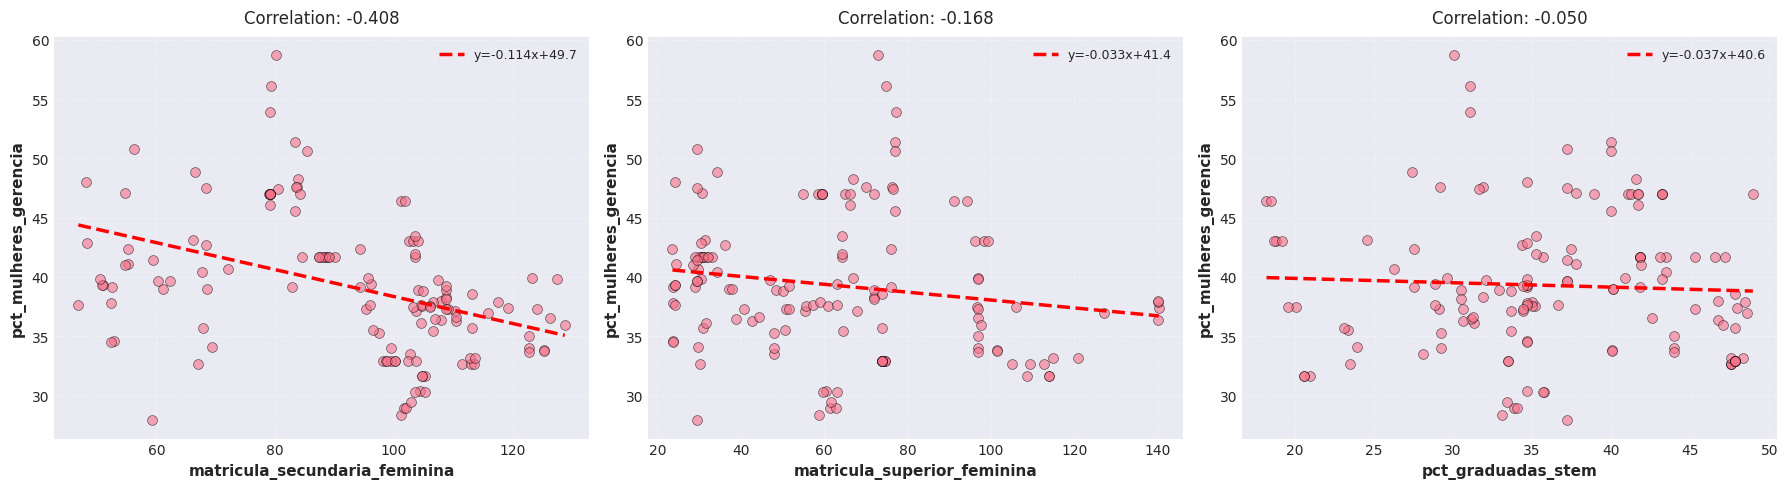

In [11]:
# Select top features for visualization
education_corr['abs_corr'] = education_corr['Correlation'].abs()

top_features = education_corr.nlargest(
    min(3, len(education_corr)), 
    'abs_corr'
)['Feature'].values

fig, axes = plt.subplots(1, min(3, len(top_features)), figsize=(18, 5))
if len(top_features) == 1:
    axes = [axes]

for idx, feature in enumerate(top_features):
    ax = axes[idx]
        
    # Scatter plot
    ax.scatter(X[feature], y, alpha=0.6, edgecolors='k', linewidth=0.5, s=50)
        
    # Regression line
    mask = X[feature].notna() & y.notna()
    if mask.sum() > 1:
        z = np.polyfit(X[feature][mask], y[mask], 1)
        p = np.poly1d(z)
        x_line = np.linspace(X[feature][mask].min(), X[feature][mask].max(), 100)
        ax.plot(x_line, p(x_line), "r--", linewidth=2.5, label=f'y={z[0]:.3f}x+{z[1]:.1f}')
        
    # Styling
    corr = X[feature].corr(y)
    ax.set_xlabel(feature, fontsize=11, fontweight='bold')
    ax.set_ylabel('pct_mulheres_gerencia', fontsize=11, fontweight='bold')
    ax.set_title(f'Correlation: {corr:.3f}', fontsize=12, pad=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')
    
plt.tight_layout()
plt.show()

## Question 2: how does economic development influence gender equality?

In [12]:
# Identify economic indicators
economic_features = ['pib_per_capita',
                     'indice_gini']

for i, feat in enumerate(economic_features, 1):
    print(f"   {i}. {feat}")

# Calculate correlations with target
economic_corr = pd.DataFrame({
    'Feature': economic_features,
    'Correlation': [X[feat].corr(y) for feat in economic_features]
}).sort_values('Correlation', ascending=False, key=abs)
    
print(f"\nCorrelations with female leadership:")
print(economic_corr.to_string(index=False))

   1. pib_per_capita
   2. indice_gini

Correlations with female leadership:
       Feature  Correlation
   indice_gini    -0.061855
pib_per_capita     0.012470


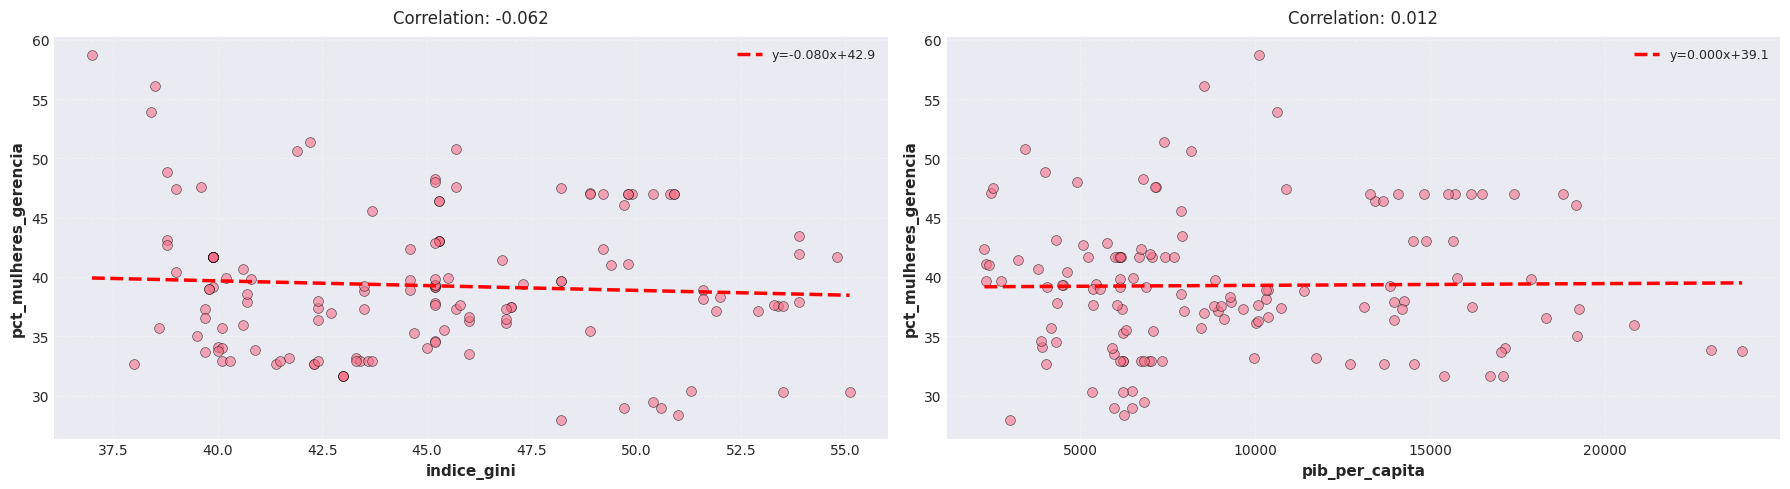

In [13]:
# Select top features for visualization
economic_corr['abs_corr'] = economic_corr['Correlation'].abs()

top_features = economic_corr.nlargest(
    min(2, len(economic_corr)), 
    'abs_corr'
)['Feature'].values

fig, axes = plt.subplots(1, min(2, len(top_features)), figsize=(18, 5))
if len(top_features) == 1:
    axes = [axes]

for idx, feature in enumerate(top_features):
    ax = axes[idx]
        
    # Scatter plot
    ax.scatter(X[feature], y, alpha=0.6, edgecolors='k', linewidth=0.5, s=50)
        
    # Regression line
    mask = X[feature].notna() & y.notna()
    if mask.sum() > 1:
        z = np.polyfit(X[feature][mask], y[mask], 1)
        p = np.poly1d(z)
        x_line = np.linspace(X[feature][mask].min(), X[feature][mask].max(), 100)
        ax.plot(x_line, p(x_line), "r--", linewidth=2.5, label=f'y={z[0]:.3f}x+{z[1]:.1f}')
        
    # Styling
    corr = X[feature].corr(y)
    ax.set_xlabel(feature, fontsize=11, fontweight='bold')
    ax.set_ylabel('pct_mulheres_gerencia', fontsize=11, fontweight='bold')
    ax.set_title(f'Correlation: {corr:.3f}', fontsize=12, pad=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')
    
plt.tight_layout()
plt.show()

## Question 3: what is the relationship between employment quality and female leadership?

In [14]:
employment_features = ['participacao_trabalho_feminina',
                       'razao_fm_participacao_trabalho',
                       'desemprego_feminino',
                       'desemprego_masculino',
                       'desemprego_edu_avancada_feminino',
                       'desemprego_edu_avancada_masculino',
                       'empregadas_assalariadas',
                       'empregados_assalariados']

for i, feat in enumerate(employment_features, 1):
    print(f"   {i}. {feat}")

# Calculate correlations
if len(employment_features) > 0:
    employment_corr = pd.DataFrame({
        'Feature': employment_features,
        'Correlation': [X[feat].corr(y) for feat in employment_features]
    }).sort_values('Correlation', ascending=False, key=abs)
    
    print(f"\nCorrelations with female leadership:")
    print(employment_corr.to_string(index=False))
else:
    print("No employment features found")
    employment_features = []

   1. participacao_trabalho_feminina
   2. razao_fm_participacao_trabalho
   3. desemprego_feminino
   4. desemprego_masculino
   5. desemprego_edu_avancada_feminino
   6. desemprego_edu_avancada_masculino
   7. empregadas_assalariadas
   8. empregados_assalariados

Correlations with female leadership:
                          Feature  Correlation
   razao_fm_participacao_trabalho    -0.255744
   participacao_trabalho_feminina    -0.229479
             desemprego_masculino    -0.228218
          empregados_assalariados    -0.148231
desemprego_edu_avancada_masculino    -0.146648
          empregadas_assalariadas     0.078316
 desemprego_edu_avancada_feminino    -0.024543
              desemprego_feminino     0.002579


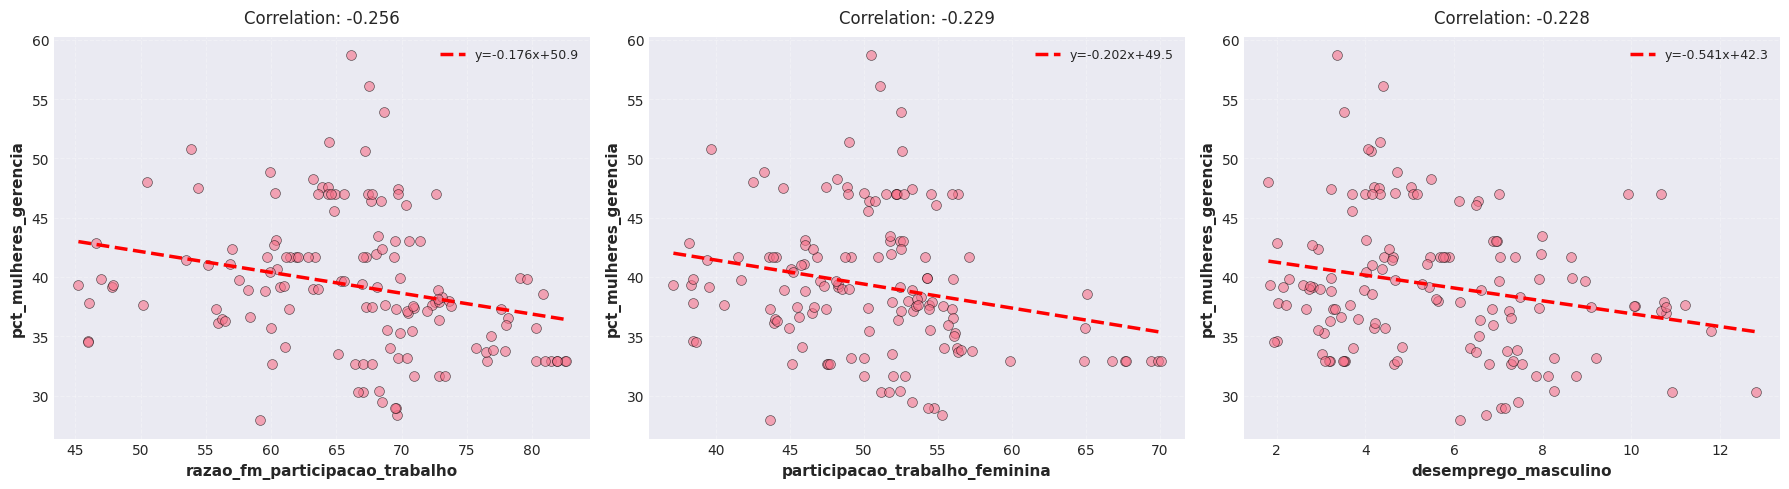

In [15]:
# Select top features for visualization
employment_corr['abs_corr'] = employment_corr['Correlation'].abs()

top_features = employment_corr.nlargest(
    min(3, len(employment_features)), 
    'abs_corr'
)['Feature'].values

fig, axes = plt.subplots(1, min(3, len(top_features)), figsize=(18, 5))
if len(top_features) == 1:
    axes = [axes]

for idx, feature in enumerate(top_features):
    ax = axes[idx]
        
    # Scatter plot
    ax.scatter(X[feature], y, alpha=0.6, edgecolors='k', linewidth=0.5, s=50)
        
    # Regression line
    mask = X[feature].notna() & y.notna()
    if mask.sum() > 1:
        z = np.polyfit(X[feature][mask], y[mask], 1)
        p = np.poly1d(z)
        x_line = np.linspace(X[feature][mask].min(), X[feature][mask].max(), 100)
        ax.plot(x_line, p(x_line), "r--", linewidth=2.5, label=f'y={z[0]:.3f}x+{z[1]:.1f}')
        
    # Styling
    corr = X[feature].corr(y)
    ax.set_xlabel(feature, fontsize=11, fontweight='bold')
    ax.set_ylabel('pct_mulheres_gerencia', fontsize=11, fontweight='bold')
    ax.set_title(f'Correlation: {corr:.3f}', fontsize=12, pad=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')
    
plt.tight_layout()
plt.show()

# 5. Predictive modeling

In [16]:
# Train models
analyzer.train_models(test_size=0.2, random_state=42)

Training models...

   Training Linear Regression...
      R² Test: 0.6773
      MAE Test: 2.4286
      CV R²: 0.2522 ± 0.2719

   Training Random Forest...
      R² Test: 0.8525
      MAE Test: 1.7226
      CV R²: 0.5098 ± 0.2049

   Training Gradient Boosting...
      R² Test: 0.8888
      MAE Test: 1.3354
      CV R²: 0.5254 ± 0.0925

All models trained!


{'Linear Regression': LinearRegression(),
 'Random Forest': RandomForestRegressor(max_depth=10, random_state=42),
 'Gradient Boosting': GradientBoostingRegressor(max_depth=5, random_state=42)}

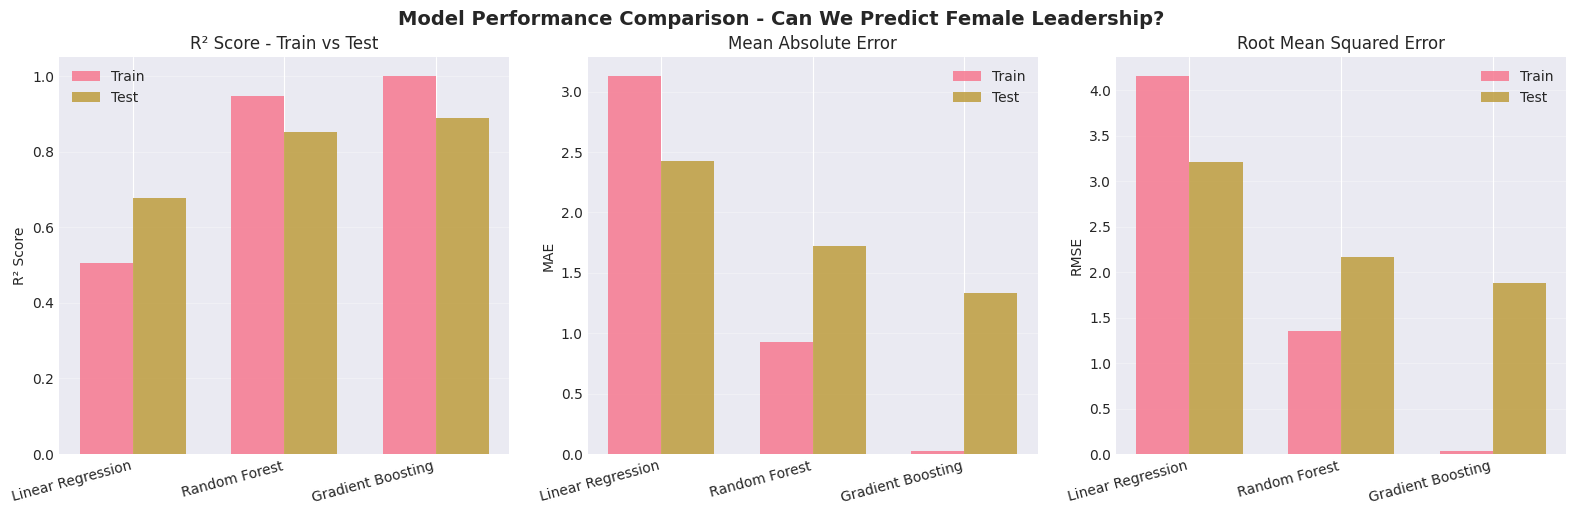


Detailed Metrics:
                   train_r2   test_r2  train_mae  test_mae  train_rmse  test_rmse  cv_r2_mean  cv_r2_std
Linear Regression  0.505535  0.677294   3.127165  2.428609    4.154992   3.211343    0.252164   0.271892
Random Forest      0.947793  0.852492   0.925033  1.722649    1.350101   2.171156    0.509769   0.204908
Gradient Boosting  0.999974  0.888768   0.024539  1.335401    0.029964   1.885375    0.525396   0.092454

Best Model: Gradient Boosting
   R² Score: 0.8888 (88.9% of variance explained)
   MAE: 1.3354 percentage points
   Models explain 88.9% of variation with 1.34pp average error.


In [17]:
comparison = analyzer.plot_model_comparison(figsize=(16, 5))
plt.suptitle('Model Performance Comparison - Can We Predict Female Leadership?', 
             fontsize=14, fontweight='bold', y=1.02)
plt.show()

print("\nDetailed Metrics:")
print(comparison.to_string())

# Best model
best_model = comparison['test_r2'].idxmax()
best_r2 = comparison.loc[best_model, 'test_r2']
best_mae = comparison.loc[best_model, 'test_mae']

print(f"\nBest Model: {best_model}")
print(f"   R² Score: {best_r2:.4f} ({best_r2*100:.1f}% of variance explained)")
print(f"   MAE: {best_mae:.4f} percentage points")
print(f"   Models explain {best_r2*100:.1f}% of variation with {best_mae:.2f}pp average error.")

## Question 4: which interventions provide the highest ROI?

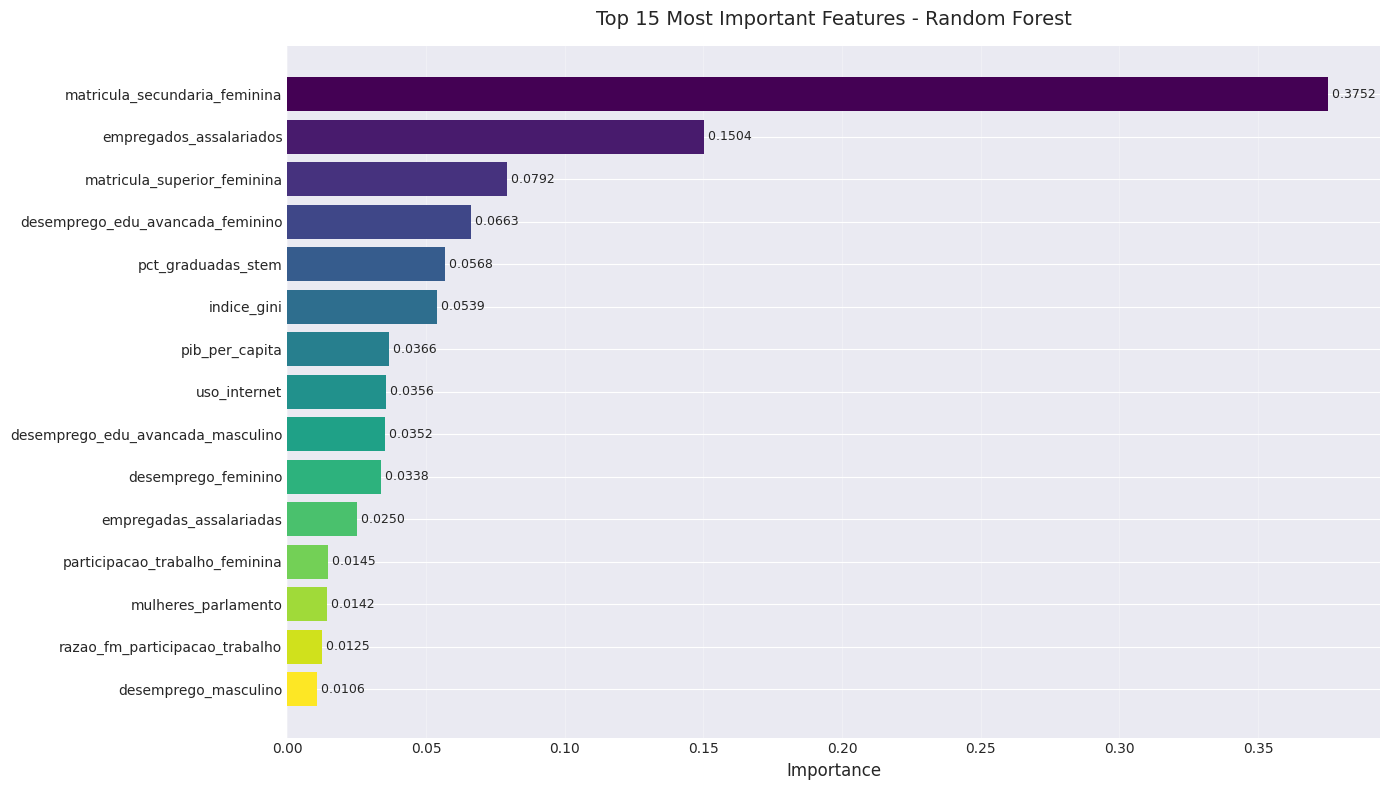


Top 10 Most Important Features:
                          Feature  Importance
    matricula_secundaria_feminina    0.375203
          empregados_assalariados    0.150404
      matricula_superior_feminina    0.079228
 desemprego_edu_avancada_feminino    0.066337
               pct_graduadas_stem    0.056819
                      indice_gini    0.053930
                   pib_per_capita    0.036561
                     uso_internet    0.035570
desemprego_edu_avancada_masculino    0.035202
              desemprego_feminino    0.033827

STRATEGIC PRIORITIZATION (Q4)

Based on feature importance, prioritize interventions in:

8. matricula_secundaria_feminina
   Impact Score: 0.3752
   → HIGH ROI candidate for policy intervention

6. empregados_assalariados
   Impact Score: 0.1504
   → HIGH ROI candidate for policy intervention

9. matricula_superior_feminina
   Impact Score: 0.0792
   → HIGH ROI candidate for policy intervention

1. desemprego_edu_avancada_feminino
   Impact Score: 0.0663


In [18]:
importance_df = analyzer.plot_feature_importance('Random Forest', top_n=15, figsize=(14, 8))
plt.show()

print("\nTop 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))

print("\n" + "=" * 80)
print("STRATEGIC PRIORITIZATION (Q4)")
print("=" * 80)
print("\nBased on feature importance, prioritize interventions in:")
for idx, row in importance_df.head(5).iterrows():
    print(f"\n{idx+1}. {row['Feature']}")
    print(f"   Impact Score: {row['Importance']:.4f}")
    print(f"   → HIGH ROI candidate for policy intervention")